# Generative BIM Cost Optimisation

### What This Code Demonstrates

1. **Parametric BIM Mapping:** Maps physical material metadata (costs per $\text{m}^3$, density, yield strengths) to parametric geometry ($b$, $d$).
2. **Generative Optimization:** Uses an evolutionary genetic algorithm to explore the structural solution space rather than relying on standard pre-set sizing tables.
3. **Multi-Constraint Checking:** Enforces structural mechanics rules (bending moment stress limits and deflection limits $L/360$) directly within the objective function loop.


### Step-by-Step Breakdown of the Pipeline

#### 1. Parameterization & BIM Data Extraction (Stage 1)

- **What happens:** Physical attributes from a BIM model are defined as computational variables and constants.
- **In the code:**
  - `MATERIALS` acts as the BIM database holding unit costs ($\$/\text{m}^3$ for concrete, $\$ /\text{kg}$ for rebar) and material properties (yield strength, density).
  - `design_bounds` defines the search space for the generative engine: width ($b \in [200, 600]\text{ mm}$) and depth ($d \in [300, 1000]\text{ mm}$).

#### 2. Generative Candidate Generation (Stage 2)

- **What happens:** Instead of a human guessing beam sizes, an evolutionary engine proposes hundreds of design candidates ($b, d$) per generation.
- **In the code:**
  - `differential_evolution()` initializes a population of candidate beam profiles. Over multiple iterations, it combines traits of the lowest-cost designs to evolve more efficient configurations.

#### 3. BIM Quantity Take-Off & Structural Analysis (Stage 3)

- **What happens:** Each candidate design is simultaneously evaluated for cost and physical safety.
- **In the code:**
  - **Cost Calculation:** $V = b \times d \times L$. Volume is multiplied by unit prices from the BIM database to get exact dollar costs.
  - **Structural Physics:** The code calculates moment of inertia ($I$), bending stress ($\sigma$), and deflection ($\delta$) using beam mechanics equations.

#### 4. The Penalty Function (Constraint Enforcement) (Stage 4)

- **What happens:** In generative design, constraints are enforced by applying artificial "financial penalties" to candidates that violate engineering standards.
- **In the code:**
  - If bending stress exceeds $15\text{ MPa}$ or deflection exceeds the $L/360$ safety limit, a large mathematical penalty is added to the total cost.
  - This forces the genetic algorithm to automatically abandon unsafe or failing structural geometries.

#### 5. Convergence & Data Push Back to BIM (Stage 5)

- **What happens:** The algorithm finds the global minimum—the smallest, least expensive beam profile that still complies with structural limits—and produces data visualization for engineering approval.
- **In the code:**
  - The final optimal parameters ($b^\*, d^\*$) and total cost are extracted.
  - The 2D contour map plots the **Design Space**, showing how the algorithm isolated the optimal design point (red star) right at the edge of safety and cost efficiency.

# Example

### Stage 1: Data Input & Parameterization

* **In the Concept:** Defining real-world material costs, material physics, and physical limits.
* **In the Jupyter Code:** Executed in the **first code block** via Python dictionaries and global variables.

#### Parametric Search Space (Bounds for b and d)
design_bounds = [(0.20, 0.60), (0.30, 1.00)]


**How it works:** This acts as the API connection to a BIM database. Instead of hardcoding beam sizes, we define allowable **ranges** (`design_bounds`) that the AI is permitted to explore.


In [1]:
# Stage 1: Data Input & Parameterization
# ==============================================================================
# JUPYTER NOTEBOOK: Generative Design & BIM Cost Optimization Example
# Objective: Optimize structural beam sizes to minimize material cost ($)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# ------------------------------------------------------------------------------
# 1. SETUP BIM-STYLE MATERIAL COST & STRUCTURAL PROPERTIES
# ------------------------------------------------------------------------------
# Mock BIM Database: Material unit costs and mechanical properties    # step 1
MATERIALS = {
    'Concrete_C30': {
        'cost_per_m3': 120.0,   # $ / m^3
        'density': 2400.0,       # kg / m^3
    },
    'Steel_Rebar_A615': {
        'cost_per_kg': 1.25,     # $ / kg
        'density': 7850.0,       # kg / m^3
        'yield_strength': 420e6, # Pa (420 MPa)
        'E_modulus': 200e9       # Pa (200 GPa)
    }
}

# Parametric Search Space (Bounds for b and d)
# design_bounds = [(0.20, 0.60), (0.30, 1.00)]

# Building Structure Constraints
SPAN_LENGTH = 8.0     # 8 meter span per beam
TOTAL_BEAMS = 50      # Total beams across the building structure
MAX_DEFLECTION = SPAN_LENGTH / 360.0  # L/360 serviceability limit (0.0222 m)

# Applied Design Bending Moment and Shear Force per beam (from load analysis)
DESIGN_MOMENT = 180e3 # 180 kNm
REBAR_RATIO = 0.015   # Fixed 1.5% steel reinforcement ratio by volume

print("--- BIM Parameter Database Loaded ---")
print(f"Span: {SPAN_LENGTH}m | Max Allowed Deflection: {MAX_DEFLECTION*1000:.2f} mm")

--- BIM Parameter Database Loaded ---
Span: 8.0m | Max Allowed Deflection: 22.22 mm


In [2]:
# ------------------------------------------------------------------------------
# 2. DEFINE STRUCTURAL EVALUATION & COST FUNCTION
# ------------------------------------------------------------------------------
def evaluate_beam_cost_and_safety(params):
    """
    Evaluates a generated beam design.
    params: [b (width in meters), d (depth in meters)]
    Returns: total cost ($) + penalty if structural constraints are violated.
    """
    b, d = params
    
    # 1. Calculate Geometry & Volume
    area_concrete = b * d
    vol_concrete = area_concrete * SPAN_LENGTH
    
    vol_steel = vol_concrete * REBAR_RATIO
    mass_steel = vol_steel * MATERIALS['Steel_Rebar_A615']['density']
    
    # 2. Material Cost Calculation (BIM QTO - Quantity Take-Off)
    cost_concrete = vol_concrete * MATERIALS['Concrete_C30']['cost_per_m3']
    cost_steel = mass_steel * MATERIALS['Steel_Rebar_A615']['cost_per_kg']
    total_material_cost = cost_concrete + cost_steel
    
    # 3. Structural Mechanics Verification (FEA Approximation)
    # Moment of Inertia (I = b * d^3 / 12)
    I_gross = (b * (d ** 3)) / 12.0
    
    # Equivalent Bending Stress: sigma = M * (d/2) / I
    stress = DESIGN_MOMENT * (d / 2.0) / I_gross
    
    # Bending Deflection under load: delta = (5 * M * L^2) / (48 * E * I)
    E_eff = 30e9  # Effective composite modulus (~30 GPa)
    deflection = (5.0 * DESIGN_MOMENT * (SPAN_LENGTH**2)) / (48.0 * E_eff * I_gross)
    
    # 4. Penalty Function for Constraint Violations (Generative Filtering)
    penalty = 0.0
    
    # Structural Safety Constraint (Max stress vs allowable yield)
    allowable_stress = 15e6 # 15 MPa allowable flexural stress for concrete
    if stress > allowable_stress:
        penalty += (stress - allowable_stress) * 100  # High penalty for structural failure
        
    # Serviceability Constraint (Deflection Limit)
    if deflection > MAX_DEFLECTION:
        penalty += (deflection - MAX_DEFLECTION) * 1e6
        
    return total_material_cost + penalty
    

### Stage 2: Generative Candidate Generation

* **In the Concept:** An algorithm generates multiple combinations of beam width ($b$) and depth ($d$).
* **In the Jupyter Code:** Executed in the **third code block** using SciPy’s `differential_evolution` function.

**How it works:** `differential_evolution` starts by picking 15 random pairs of $(b, d)$. It passes each pair into our evaluation function, looks at the results, keeps the cheapest safe options, and mathematically "breeds" them to create a smarter set of $(b, d)$ pairs for the next generation.


In [3]:
# Stage 2: Generative Candidate Generation

# ------------------------------------------------------------------------------
# 3. RUN GENERATIVE OPTIMIZATION ALGORITHM (Genetic Differential Evolution)
# ------------------------------------------------------------------------------
# Bounds for Generative Search:
# Width (b): 0.20m (200mm) to 0.60m (600mm)
# Depth (d): 0.30m (300mm) to 1.00m (1000mm)
design_bounds = [(0.20, 0.60), (0.30, 1.00)]

print("Executing Generative Algorithm optimization...")

# Run Evolutionary Optimization Algorithm    # Step 2
result = differential_evolution(
    evaluate_beam_cost_and_safety,           # The evaluation pipeline function
    bounds=design_bounds,                    # The search space limits
    seed=42,                                 # Genetic algorithm configuration
    popsize=15,
    maxiter=50
)

# main code used in Step 5
# Unpack the winning beam dimensions found by the AI
# opt_b, opt_d = result.x

opt_b, opt_d = result.x    # Check Step 5
opt_cost_per_beam = result.fun

print("\n=== OPTIMIZATION COMPLETE ===")
print(f"Optimal Beam Width (b) : {opt_b*1000:.1f} mm")
print(f"Optimal Beam Depth (d) : {opt_d*1000:.1f} mm")
print(f"Material Cost Per Beam : ${opt_cost_per_beam:.2f}")
print(f"Total Structural Cost ({TOTAL_BEAMS} beams): ${opt_cost_per_beam * TOTAL_BEAMS:,.2f}")

Executing Generative Algorithm optimization...

=== OPTIMIZATION COMPLETE ===
Optimal Beam Width (b) : 200.0 mm
Optimal Beam Depth (d) : 600.0 mm
Material Cost Per Beam : $256.51
Total Structural Cost (50 beams): $12,825.45


### Stage 3: BIM QTO (Quantity Take-Off) & Structural Mechanics Evaluation

* **In the Concept:** Taking a proposed pair of $(b, d)$, calculating how much material it uses, and checking if it breaks under load.
* **In the Jupyter Code:** Executed inside the `evaluate_beam_cost_and_safety` function.

**How it works:** For every single generated option, Python calculates the exact material cost in dollars using the BIM data from Stage 1, while simultaneously running engineering physics formulas ($I = \frac{b d^3}{12}$, $\sigma = \frac{M y}{I}$) to measure internal stress and bending.


### Stage 4: Penalty Function (Filtering Unsafe Designs)

* **In the Concept:** Rejecting configurations that are cheap but physically unsafe (e.g., a paper-thin beam).
* **In the Jupyter Code:** Executed at the end of the `evaluate_beam_cost_and_safety` function.

**How it works:** Optimization algorithms only know how to make numbers smaller. By adding a massive numerical penalty ($10^6$) whenever a design breaks code limits, the algorithm perceives the unsafe design as extremely "expensive," forcing it to abandon that design direction immediately.


In [4]:
# ------------------------------------------------------------------------------
# 4. GENERATE BIM DATAFRAME & VISUALIZE PARETO DESIGN SPACE
# ------------------------------------------------------------------------------
# Generate a grid of design options to map out the cost/performance landscape
widths = np.linspace(0.20, 0.60, 50)
depths = np.linspace(0.30, 1.00, 50)
W, D = np.meshgrid(widths, depths)

Cost_Grid = np.zeros_like(W)
Valid_Mask = np.zeros_like(W, dtype=bool)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        b_val, d_val = W[i, j], D[i, j]
        cost = evaluate_beam_cost_and_safety([b_val, d_val]) # Steps 3 and 4
        
        # Check if valid (no penalty applied)
        if cost < 2000:  # Reasonable cost bound without huge penalty
            Cost_Grid[i, j] = cost
            Valid_Mask[i, j] = True
        else:
            Cost_Grid[i, j] = np.nan


### Stage 5: Extraction & Visualization

* **In the Concept:** Outputting the winning parameters and mapping the design choices.
* **In the Jupyter Code:** Executed in the **fourth code block** using NumPy and Matplotlib.

**How it works:** Once the loop completes, Python extracts the optimal dimensions (`opt_b`, `opt_d`) and plots a 2D color contour chart. The chart highlights the entire cost landscape, placing a red star right at the sweet spot where material cost is minimized without crossing into structural failure.


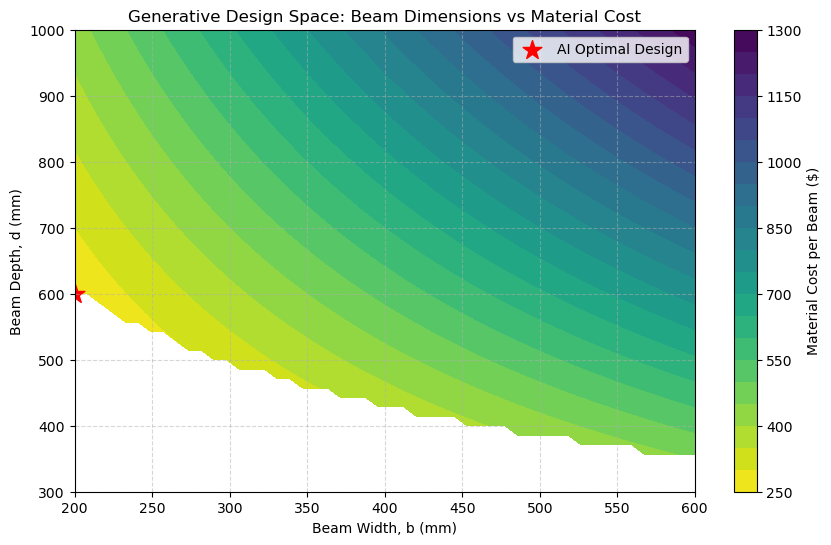

In [5]:
# Plotting the Generative Space
# Plotting the whole parameter space contour using Matplotlib

plt.figure(figsize=(10, 6))
contour = plt.contourf(W * 1000, D * 1000, Cost_Grid, levels=20, cmap='viridis_r')   # Step 5
cbar = plt.colorbar(contour)
cbar.set_label('Material Cost per Beam ($)')

# Plot Optimal Solution
plt.scatter(opt_b * 1000, opt_d * 1000, color='red', marker='*', s=200, label='AI Optimal Design')   # Step 5

plt.title('Generative Design Space: Beam Dimensions vs Material Cost', fontsize=12)
plt.xlabel('Beam Width, b (mm)')
plt.ylabel('Beam Depth, d (mm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
